In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

In [15]:
short_grbs = {
    'names': ['GRB080723913','GRB081012045','GRB081102365','GRB081105614','GRB081107321','GRB081216531',
              'GRB090108020','GRB090206620','GRB090227772','GRB090308734'],   
    'T90': [0.192, 1.216, 1.728, 1.288, 1.664, 1.664, 0.768, 0.320, 1.280, 0.448],  
    'Q_MVT':[3.9, 6.3, 6.6, 14.8, 11.4, 20.2, 6.9, 4.8, 17.2, 14.7],  # MVT with 1/f (ms)    
    'catalog_MVT': [30.7, 5.2, 25.8, 30.6, 50.4, 50.4, 13.8, 14.3, 5.3, 2.8]  # ms
}

long_grbs = {
    'names': ['GRB080723557','GRB080723985','GRB080804972','GRB080806896','GRB081650364','GRB080817161',
              'GRB080825593','GRB080906212','GRB080916009','GRB080925775','GRB081009140','GRB081101532',
              'GRB081125496','GRB081129161','GRB081221681','GRB081222204','GRB081224887','GRB090102122',
              'GRB090131090','GRB090202347','GRB090328401','GRB090411991','GRB090424592','GRB090425377',
              'GRB090528516','GRB090620400','GRB090626189','GRB090718762','GRB090809978','GRB090829672',
              'GRB090831317','GRB090926181','GRB091127976','GRB091208410','GRB100414097'],    
    'T90':[58.369, 42.817, 24.704, 75.777, 64.769, 60.289, 20.992, 2.875, 62.977, 31.744, 41.345, 8.256, 9.280, 62.657, 29.697, 18.880,
            16.448, 26.624, 35.073, 12.608, 61.697, 14.336, 14.144, 75.393, 79.041, 13.568, 48.897, 23.744, 11.008, 67.585, 39.424, 13.760, 8.701, 12.480, 26.497],   
    'Q_MVT':[36.7, 31.3, 16.1, 22.6, 34.4, 32.4, 28.8, 32.6, 32.2, 24.3, 38.3, 27.4, 26.1, 45.2, 37.0, 37.0, 31.1, 48.7, 36.1, 26.0,
              34.4, 28.5, 90.1, 49.8, 37.6, 24.3, 88.3, 31.5, 34.7, 31.7, 29.2, 146.3, 41.5, 24.7, 42.6],  # MVT with 1/f (ms)   
    'catalog_MVT': [44.0, 189.4, 430.6, 418.9, 106.7, 191.9, 77.5, 101.1, 226.6, 174.8, 109.5, 94.8, 218.2, 91.2, 270.1, 195.6,
                    205.5, 34.7, 73.3, 144.4, 68.2, 67.3, 24.9, 134.6, 131.4, 166.7, 49.8, 162.1, 243.6, 67.8, 26.6, 43.5, 39.5, 62.1, 41.8]  # ms
}

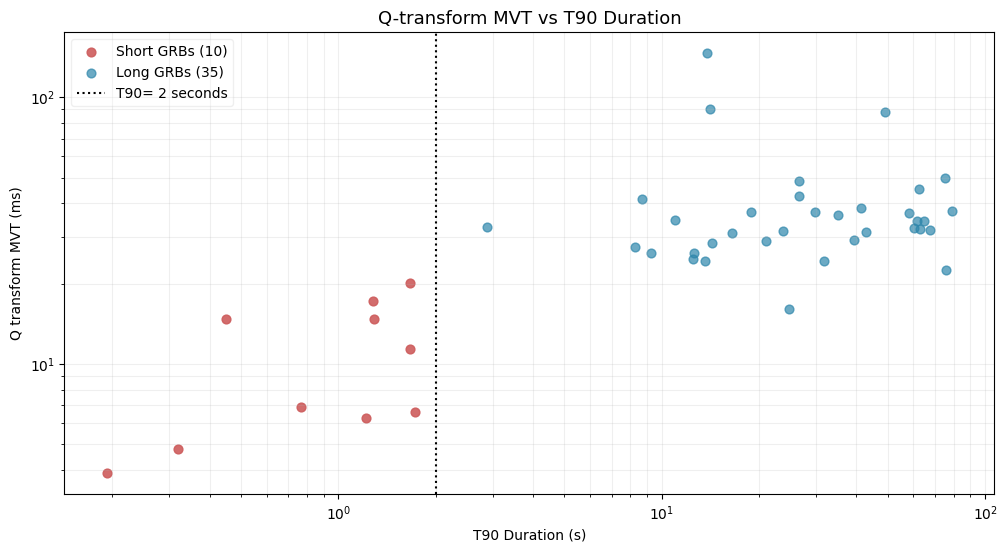

p = 0.00054430
t = -3.73710924

Short GRBs (10):
T90 range: 0.2-1.7 s
Q-MVT range: 3.9-20.2 ms

Long GRBs (35):
T90 range: 2.9-79.0 s
Q-MVT range: 16.1-146.3 ms


In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
# Short GRBs
ax.scatter(short_grbs['T90'], short_grbs['Q_MVT'], s=40, c='#cd5c5c', marker='o', alpha=0.9, linewidth=1, label=f'Short GRBs ({len(short_grbs["names"])})')
# Long GRBs
ax.scatter(long_grbs['T90'], long_grbs['Q_MVT'], s=40, c='#2e86ab', marker='o', alpha=0.7, linewidth=1, label=f'Long GRBs ({len(long_grbs["names"])})')

#ax.scatter(5.312, 36.9, c="hotpink", marker='o')

ax.set_xlabel('T90 Duration (s)')
ax.set_xscale('log')
ax.set_ylabel('Q transform MVT (ms)')
ax.set_yscale('log')
ax.axvline(2, color='black', linestyle=':', label='T90= 2 seconds') # T90 = 2 seconds
ax.legend(loc='upper left', framealpha=0.3, fontsize=10)
ax.set_title('Q-transform MVT vs T90 Duration', fontsize=13)
ax.grid(True, alpha=0.2, which='both')
plt.savefig('population_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()

t_stat, p_value = ttest_ind(short_grbs['Q_MVT'], long_grbs['Q_MVT'])
print(f"p = {p_value:.8f}")
print(f"t = {t_stat:.8f}")

print(f"\nShort GRBs ({len(short_grbs['T90'])}):")
print(f"T90 range: {min(short_grbs['T90']):.1f}-{max(short_grbs['T90']):.1f} s")
print(f"Q-MVT range: {min(short_grbs['Q_MVT']):.1f}-{max(short_grbs['Q_MVT']):.1f} ms")
print(f"\nLong GRBs ({len(long_grbs['T90'])}):")
print(f"T90 range: {min(long_grbs['T90']):.1f}-{max(long_grbs['T90']):.1f} s")
print(f"Q-MVT range: {min(long_grbs['Q_MVT']):.1f}-{max(long_grbs['Q_MVT']):.1f} ms")

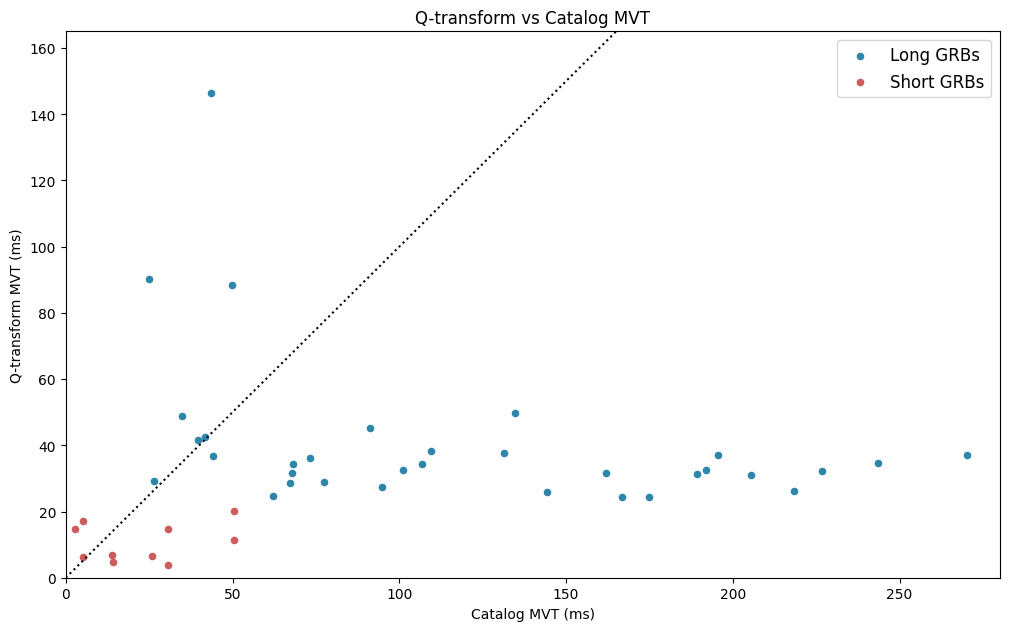

In [44]:
plt.figure(figsize=(10,6))
all_catalogs = long_grbs['catalog_MVT'] + short_grbs['catalog_MVT']
all_Q = long_grbs['Q_MVT'] + short_grbs['Q_MVT']
max_val = 300
plt.plot([0, max_val], [0, max_val], linestyle=':', color="black")
plt.scatter(long_grbs['catalog_MVT'], long_grbs['Q_MVT'], s=20, color='#2e86ab', label='Long GRBs')
plt.scatter(short_grbs['catalog_MVT'], short_grbs['Q_MVT'], s=20, color='#cd5c5c', label='Short GRBs')
ratio = max( (max(all_catalogs)), (max(all_Q)) )
plt.tight_layout()
plt.xlabel('Catalog MVT (ms)')
plt.ylabel('Q-transform MVT (ms)')
plt.title('Q-transform vs Catalog MVT')
plt.legend(fontsize=12)
plt.xlim(0, 280)
plt.ylim(0, 165)
plt.savefig('onetoone.pdf', bbox_inches='tight', dpi=300)